# 5. Evaluation: SHAP, Permutation Importance, Calibration

**Purpose:** explain model behaviour and probability calibration for classification cohorts.

**Key message:** SHAP can show that thyroid features carry some signal, but predictive value must be judged against robust CV/c-index deltas.

In [1]:
from pathlib import Path
import sys
import subprocess
import pandas as pd
import numpy as np
from IPython.display import display, Image, Markdown

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA = ROOT / 'data' / 'processed'
REPORTS = ROOT / 'reports'
FIGURES = REPORTS / 'figures'
VENV_PY = ROOT / '.venv' / 'Scripts' / 'python.exe'
PIPELINE_PY = VENV_PY if VENV_PY.exists() else Path(sys.executable)
FEATURE_SETS = [
    'CV17', 'CV17_THY26', 'CV17_BIN', 'CV17_ORD',
    'CV17_CONT', 'CV17_CAT', 'CV17_RATIO', 'CV17_RATIO_ONLY'
]

def read_csv(name, folder=DATA, **kwargs):
    path = folder / name
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path, **kwargs)

def show_image(path, width=850):
    path = Path(path)
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        print(f'Missing figure: {path}')

def run_step(step, force=False):
    cmd = [str(PIPELINE_PY), str(ROOT / 'run_pipeline.py'), '--step', step]
    if force:
        cmd.append('--force')
    print('Running:', ' '.join(cmd))
    subprocess.run(cmd, cwd=ROOT, check=True)

def pct(x):
    return f'{100*x:.1f}%'

In [2]:
RUN_PIPELINE_STEPS = True
if RUN_PIPELINE_STEPS:
    run_step('shap', force=False)
    run_step('calibration', force=False)
else:
    print('Using existing evaluation artefacts. Set RUN_PIPELINE_STEPS=True to regenerate with .venv.')

Running: c:\Users\ileni\ml4cad\.venv\Scripts\python.exe c:\Users\ileni\ml4cad\run_pipeline.py --step shap
Running: c:\Users\ileni\ml4cad\.venv\Scripts\python.exe c:\Users\ileni\ml4cad\run_pipeline.py --step calibration


## 5.1 SHAP block importance

This table summarises how much RandomForest SHAP importance is assigned to cardiovascular vs thyroid features. Legacy artefacts may only contain strict and no `cohort` column.

In [3]:
shap_path = DATA / 'shap_importance.csv'
if shap_path.exists():
    shap_df = pd.read_csv(shap_path)
    if 'cohort' not in shap_df.columns:
        shap_df.insert(0, 'cohort', 'strict_legacy')
    block = shap_df.groupby(['cohort','feature_set','group'])['mean_abs_shap'].sum().reset_index()
    display(block)
    thyroid = shap_df[shap_df['group'].eq('thyroid')].groupby(['cohort','feature_set'])['mean_abs_shap'].sum()
    total = shap_df.groupby(['cohort','feature_set'])['mean_abs_shap'].sum()
    pct_df = (100 * thyroid / total).reset_index(name='thyroid_pct_shap').fillna(0)
    display(pct_df.sort_values(['cohort','thyroid_pct_shap'], ascending=[True, False]))
else:
    print('No SHAP results.')

,cohort,feature_set,group,mean_abs_shap
0,competing,CV17,cardio,0.465741
1,competing,CV17_BIN,cardio,0.446310
2,competing,CV17_BIN,thyroid,0.039628
3,competing,CV17_CAT,cardio,0.455163
4,competing,CV17_CAT,thyroid,0.029057
5,competing,CV17_CONT,cardio,0.404218
6,competing,CV17_CONT,thyroid,0.071718
7,competing,CV17_ORD,cardio,0.459637
8,competing,CV17_ORD,thyroid,0.011434
9,competing,CV17_RATIO,cardio,0.390502


,cohort,feature_set,thyroid_pct_shap
6,competing,CV17_RATIO_ONLY,18.829650
5,competing,CV17_RATIO,18.118724
7,competing,CV17_THY26,16.005083
3,competing,CV17_CONT,15.068758
1,competing,CV17_BIN,8.155007
2,competing,CV17_CAT,6.000875
4,competing,CV17_ORD,2.427302
0,competing,CV17,0.000000
14,strict,CV17_RATIO_ONLY,16.472742
13,strict,CV17_RATIO,15.709495


## 5.2 SHAP vs permutation importance

The updated code saves both Pearson and Spearman rank correlations. Spearman is the safer communication metric for feature-ranking agreement.

In [4]:
for name in ['permutation_importance.csv', 'shap_permutation_correlation.csv']:
    path = DATA / name
    display(Markdown(f'### {name}'))
    if path.exists():
        df = pd.read_csv(path)
        display(df.head(40))
    else:
        print('Not generated yet.')

### permutation_importance.csv

,feature,perm_importance_mean,perm_importance_std,feature_set,cohort,model
0,fe,0.087501,0.009065,CV17,strict,RandomForest
1,Age,0.082795,0.007395,CV17,strict,RandomForest
2,Dyslipidemia,0.019084,0.006405,CV17,strict,RandomForest
3,Angiography,0.017824,0.007066,CV17,strict,RandomForest
4,AFib,0.016441,0.005201,CV17,strict,RandomForest
5,Angina,0.014450,0.006686,CV17,strict,RandomForest
6,Gender,0.013077,0.006233,CV17,strict,RandomForest
7,Hypertension,0.012162,0.004170,CV17,strict,RandomForest
8,PostIsch_DCM,0.011536,0.004742,CV17,strict,RandomForest
9,Smoke,0.006934,0.007121,CV17,strict,RandomForest


### shap_permutation_correlation.csv

,cohort,feature_set,n_features,pearson_corr,spearman_corr
0,competing,CV17,17,0.811389,-0.083333
1,competing,CV17_BIN,18,0.862233,0.413829
2,competing,CV17_CAT,23,0.832330,0.325099
3,competing,CV17_CONT,20,0.866487,0.354887
4,competing,CV17_ORD,18,0.834007,0.298246
5,competing,CV17_RATIO,27,0.838295,0.561661
6,competing,CV17_RATIO_ONLY,21,0.850763,0.485714
7,competing,CV17_THY26,26,0.793696,0.420855
8,strict,CV17,17,0.933626,0.617647
9,strict,CV17_BIN,18,0.940922,0.581011


## 5.3 SHAP figures

Figures are shown per cohort/feature set when available. Legacy strict-only figures are displayed as fallback.

### Cohort: strict

**CV17**

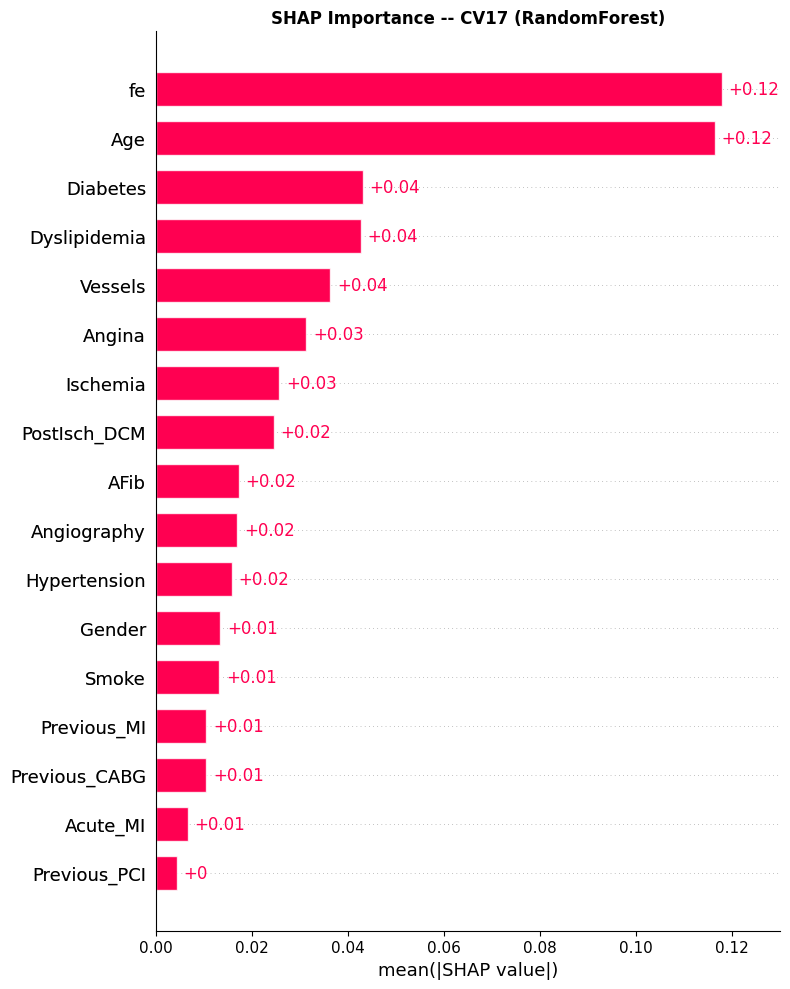

**CV17_THY26**

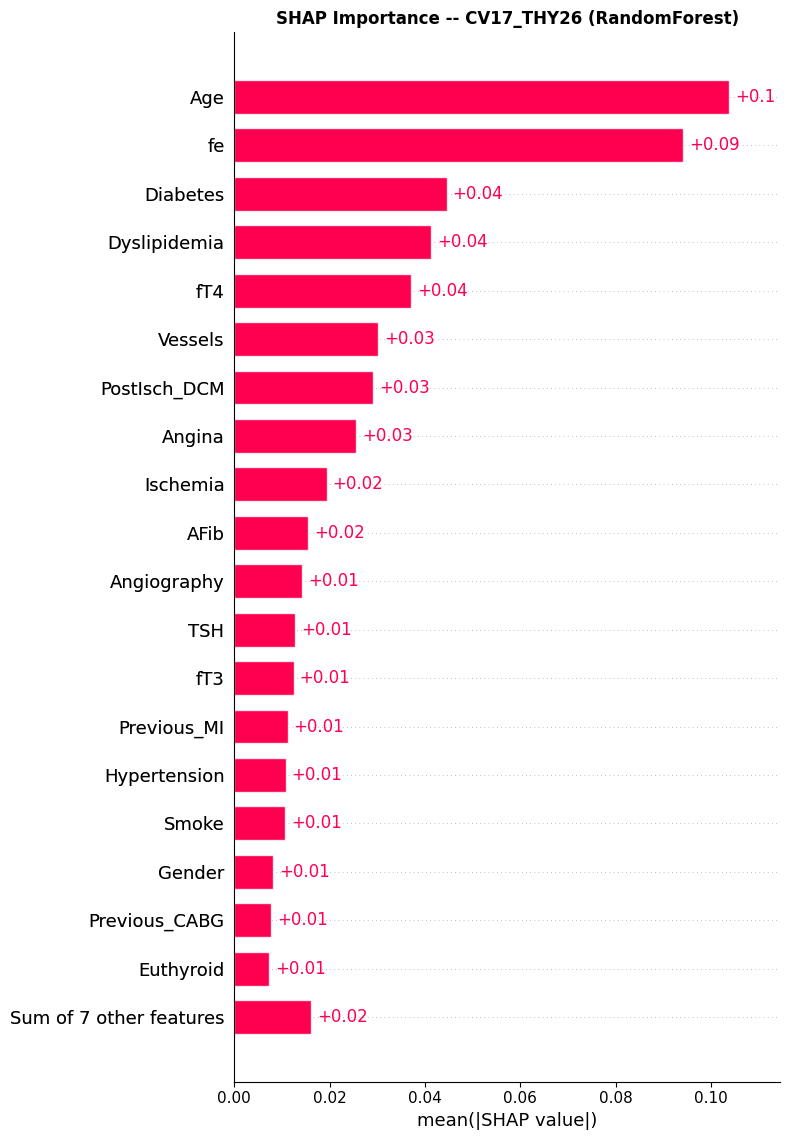

**CV17_BIN**

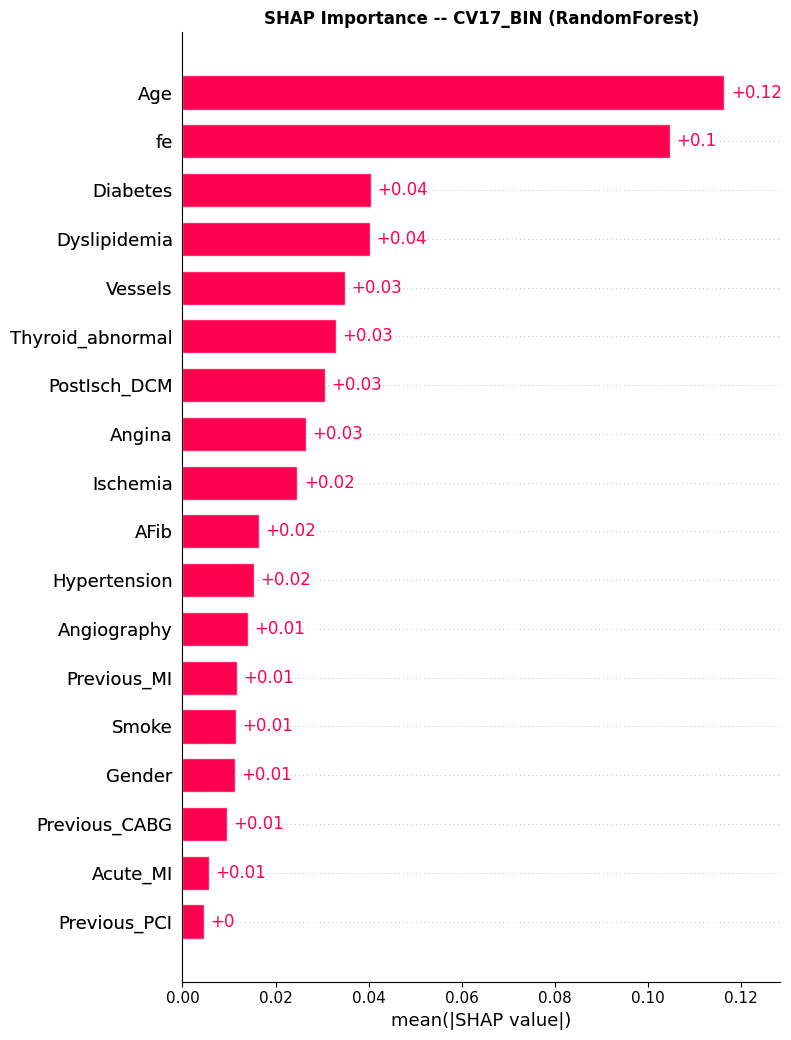

**CV17_ORD**

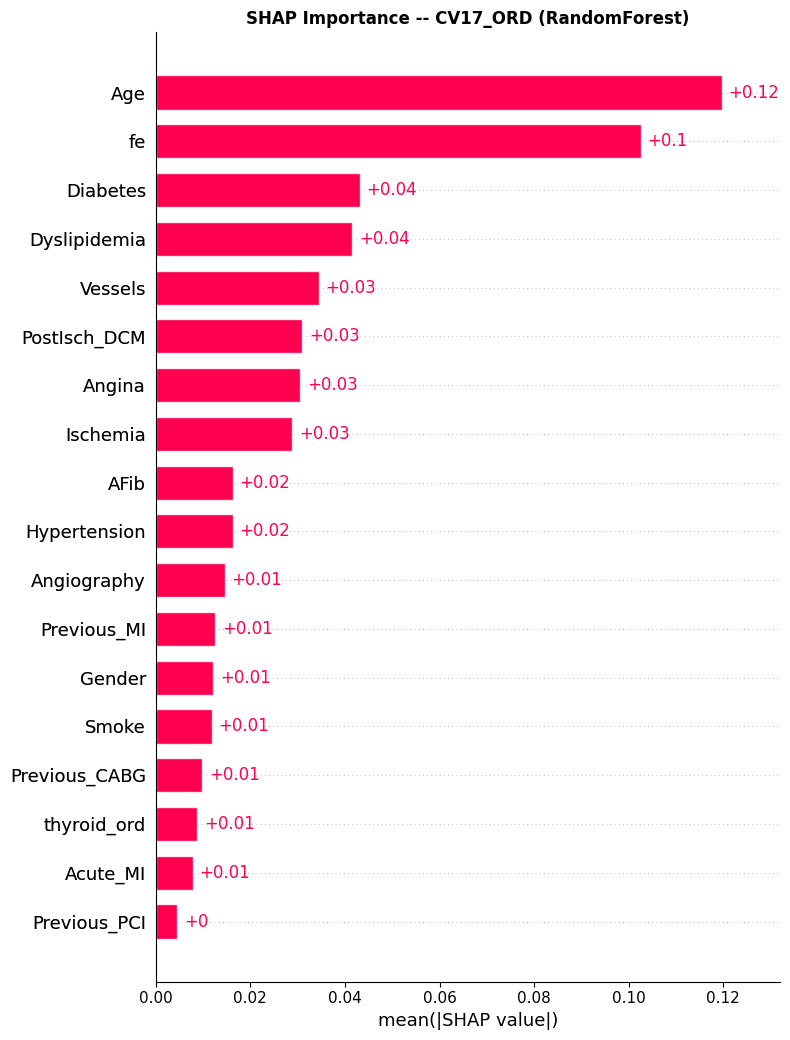

**CV17_CONT**

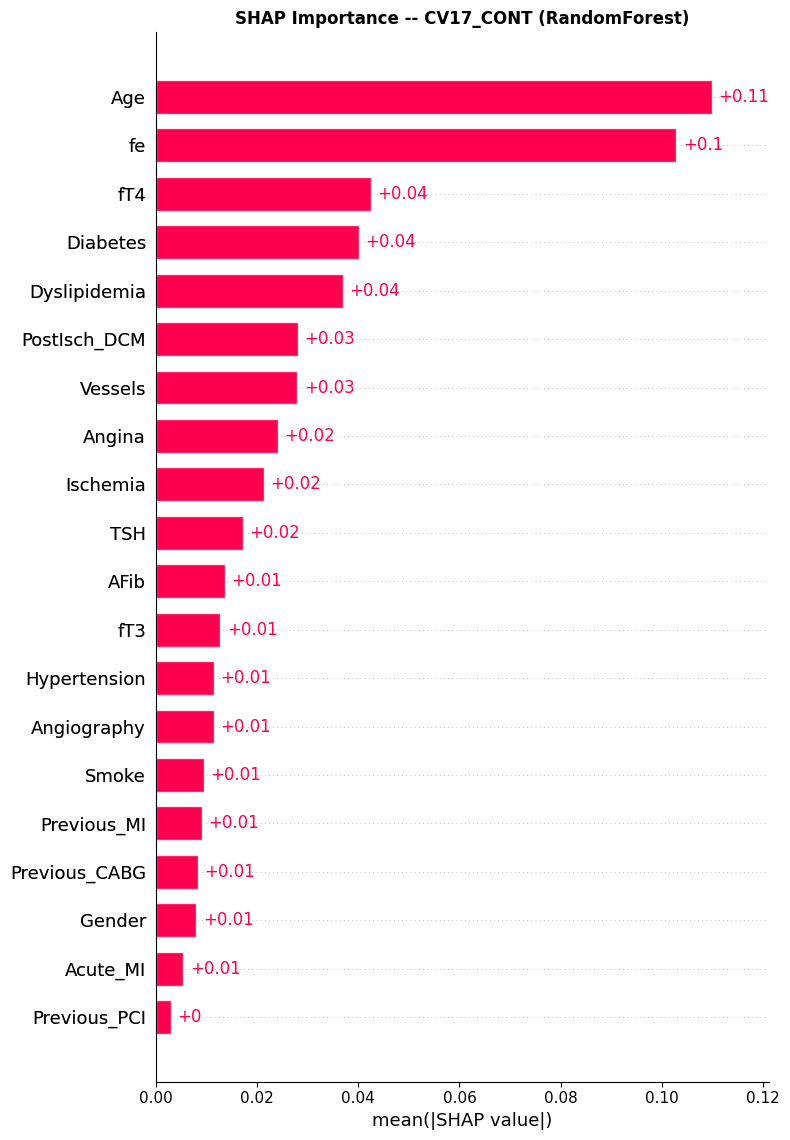

**CV17_CAT**

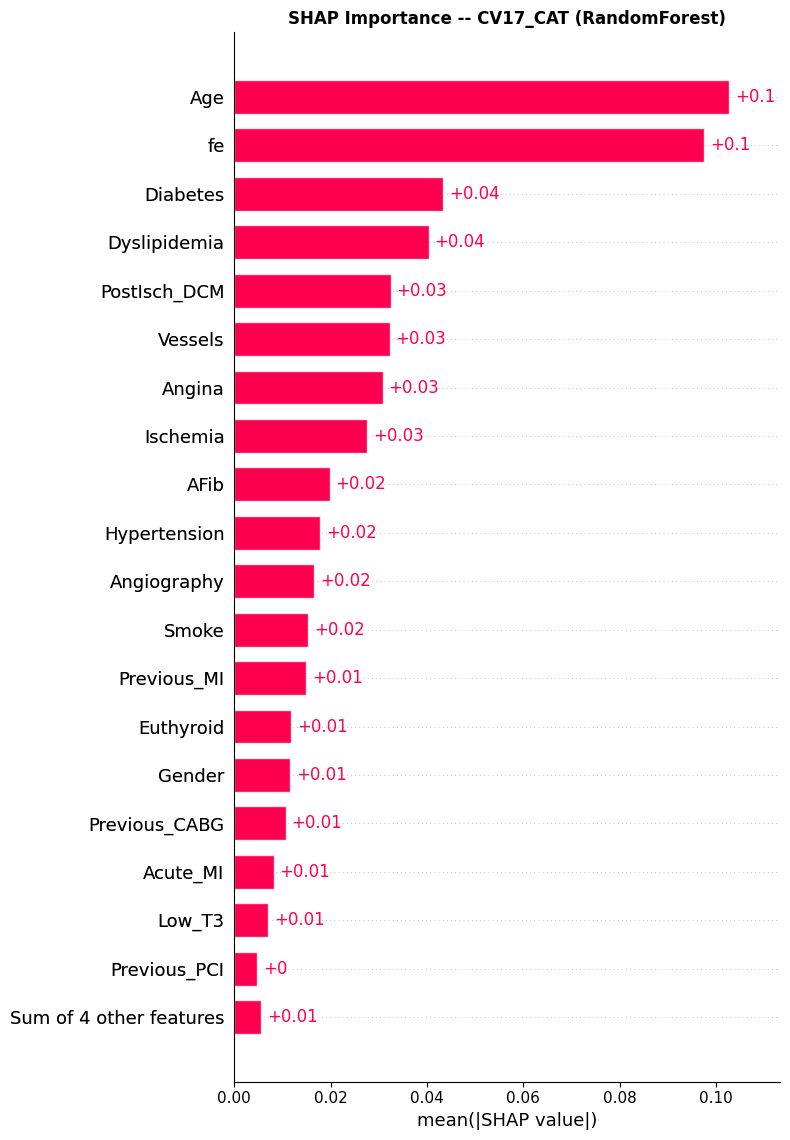

**CV17_RATIO**

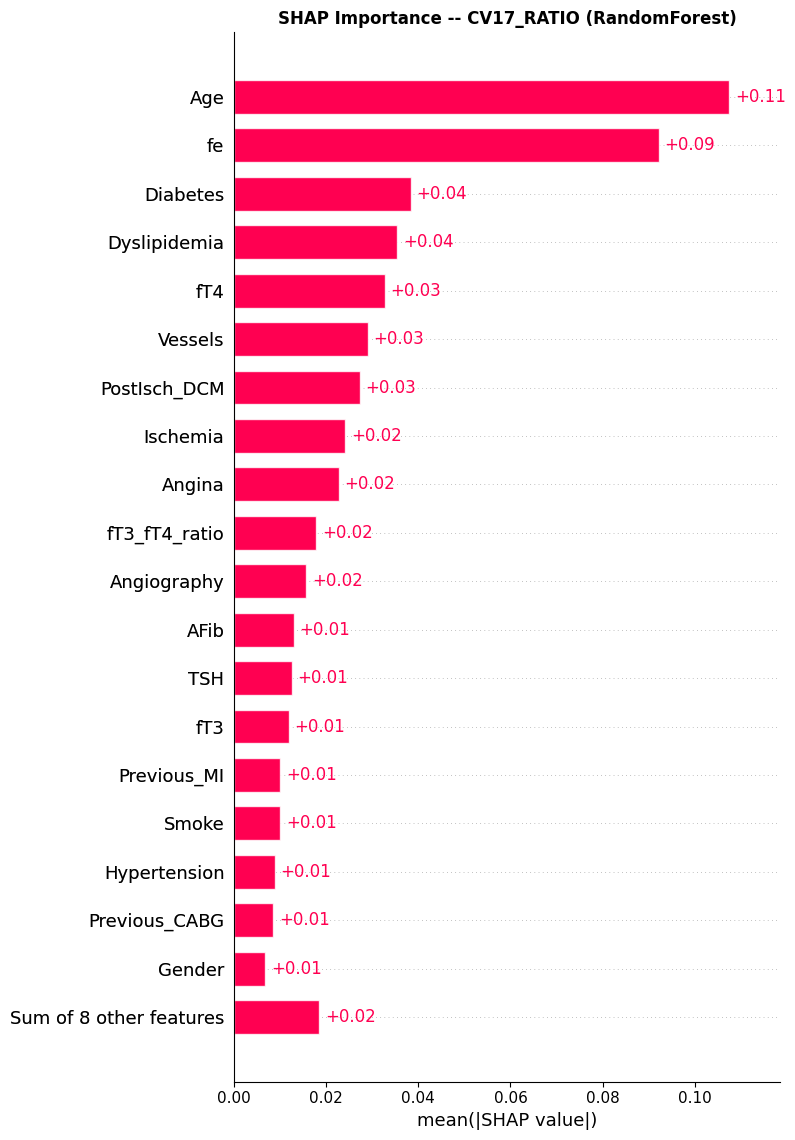

**CV17_RATIO_ONLY**

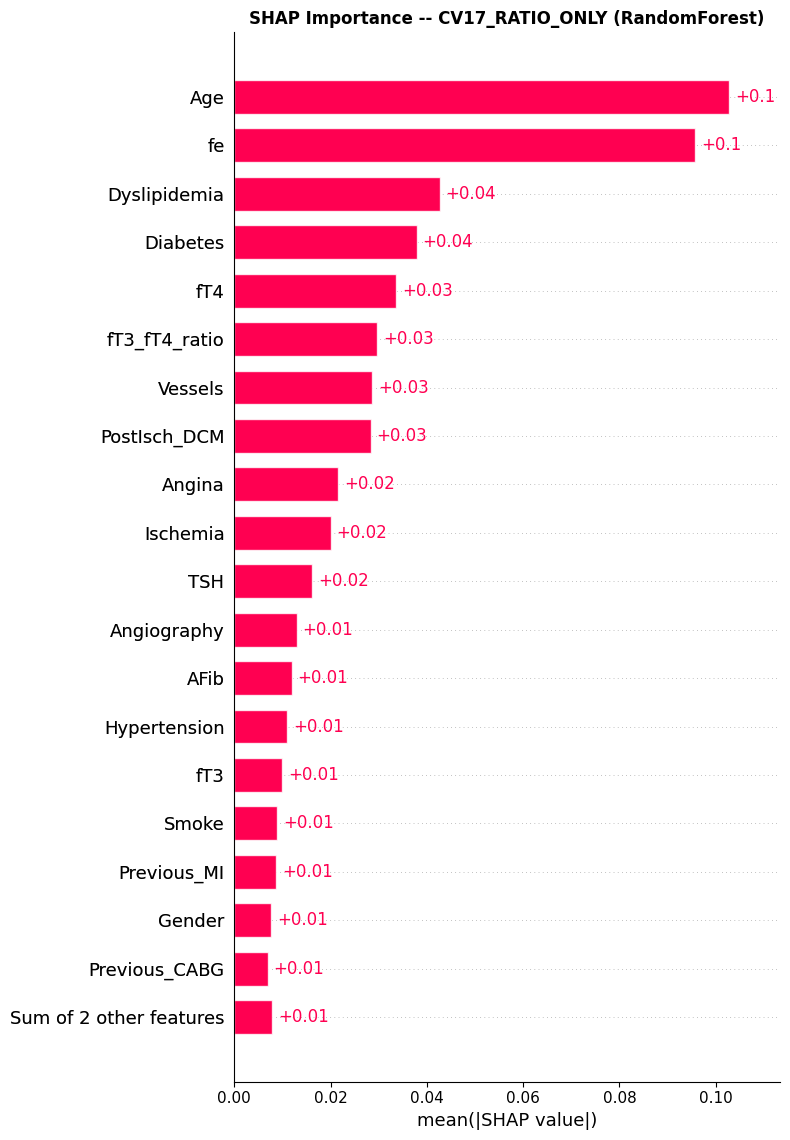

Shown figures for strict: 8


### Cohort: competing

**CV17**

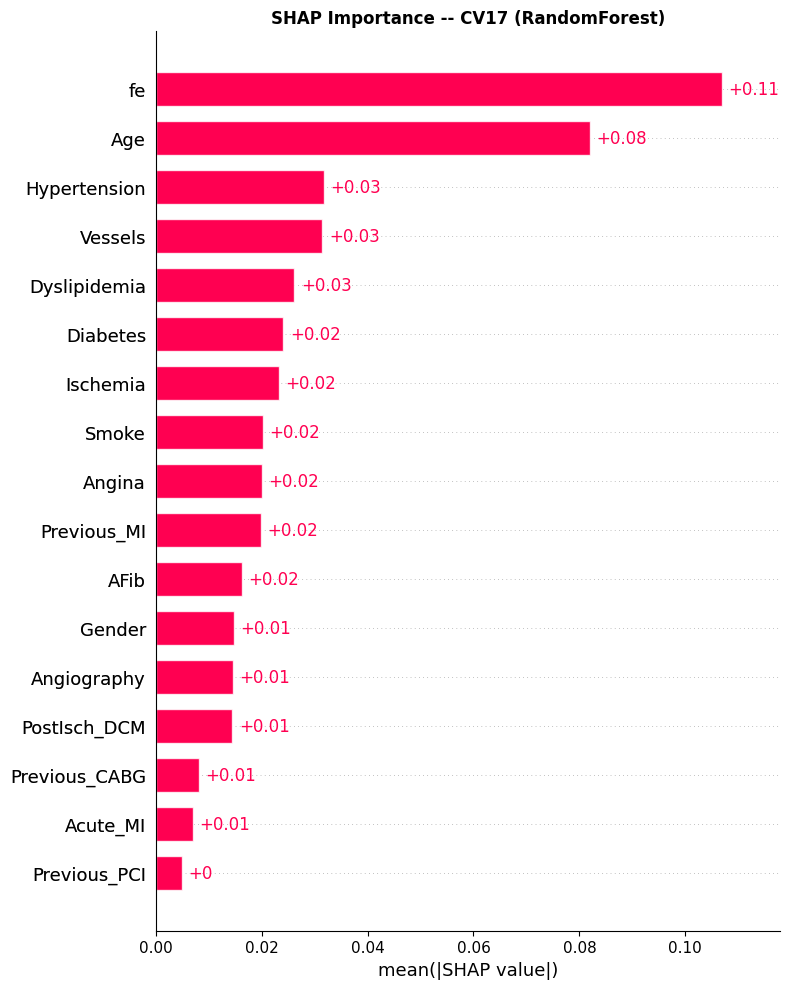

**CV17_THY26**

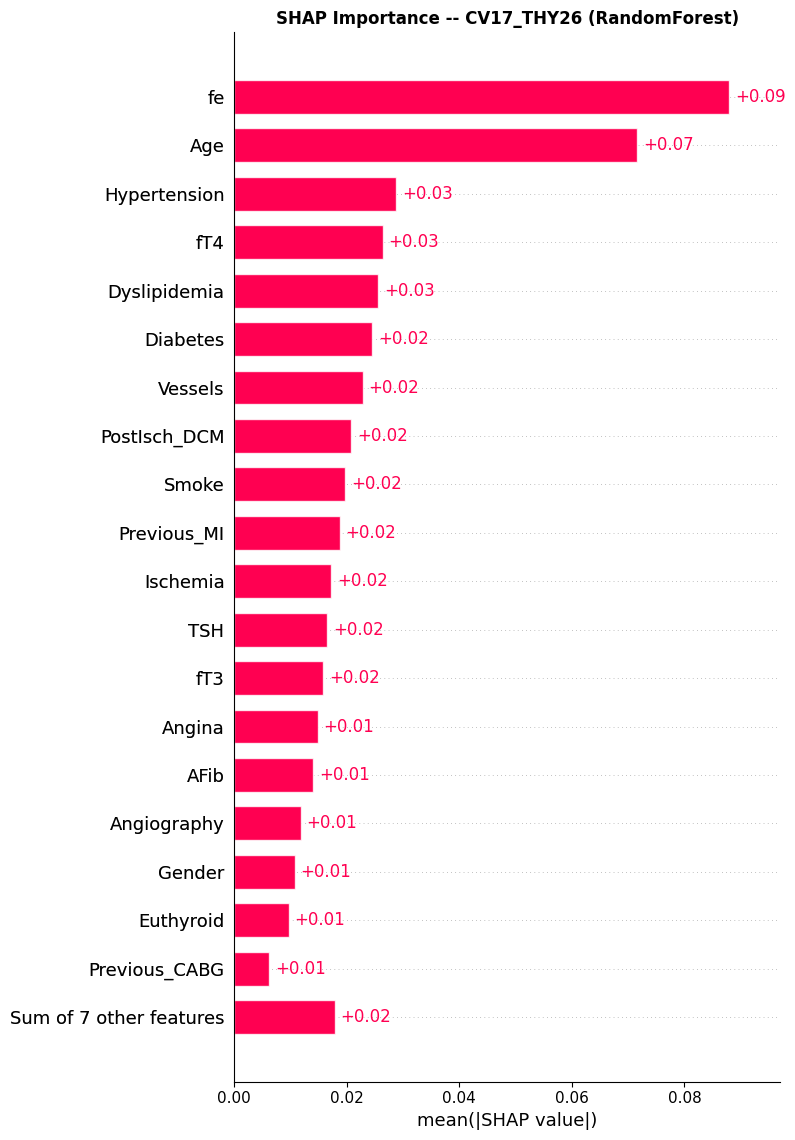

**CV17_BIN**

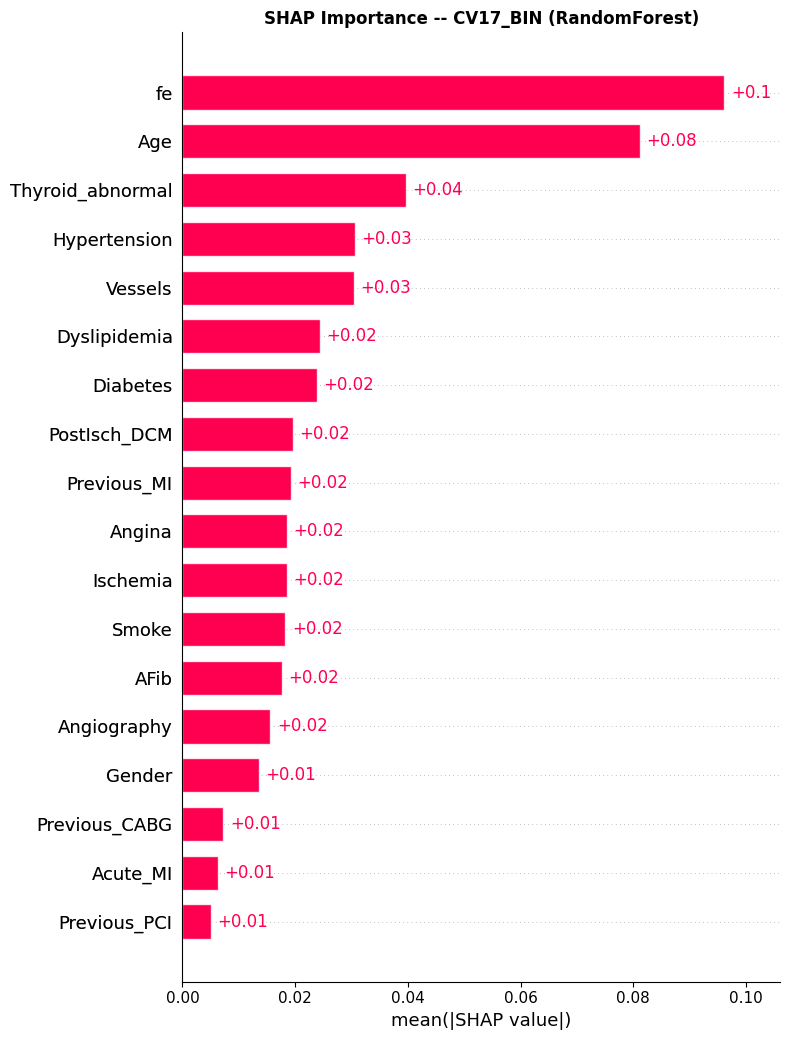

**CV17_ORD**

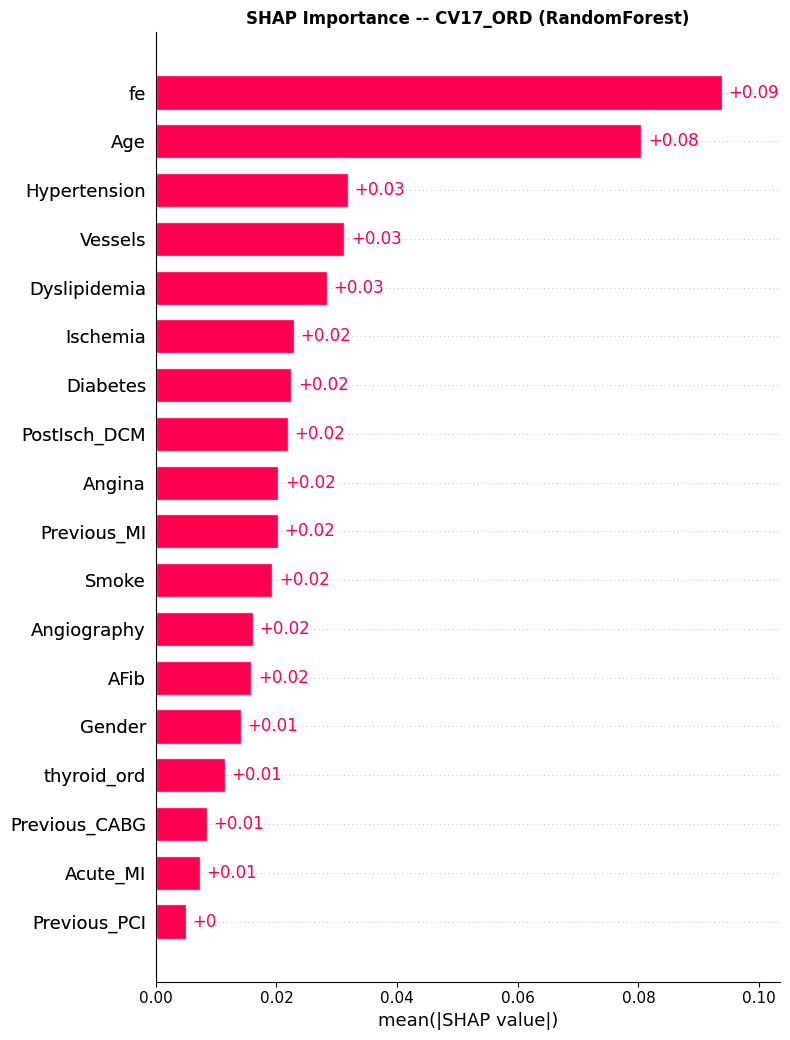

**CV17_CONT**

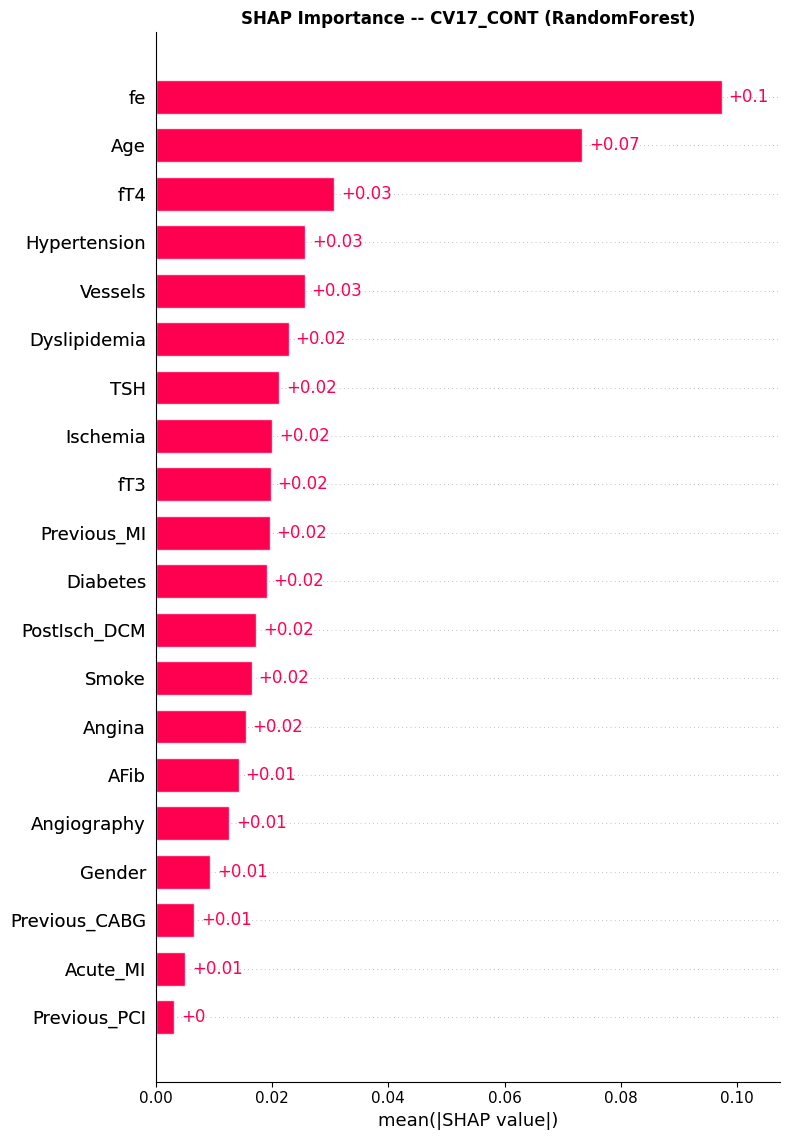

**CV17_CAT**

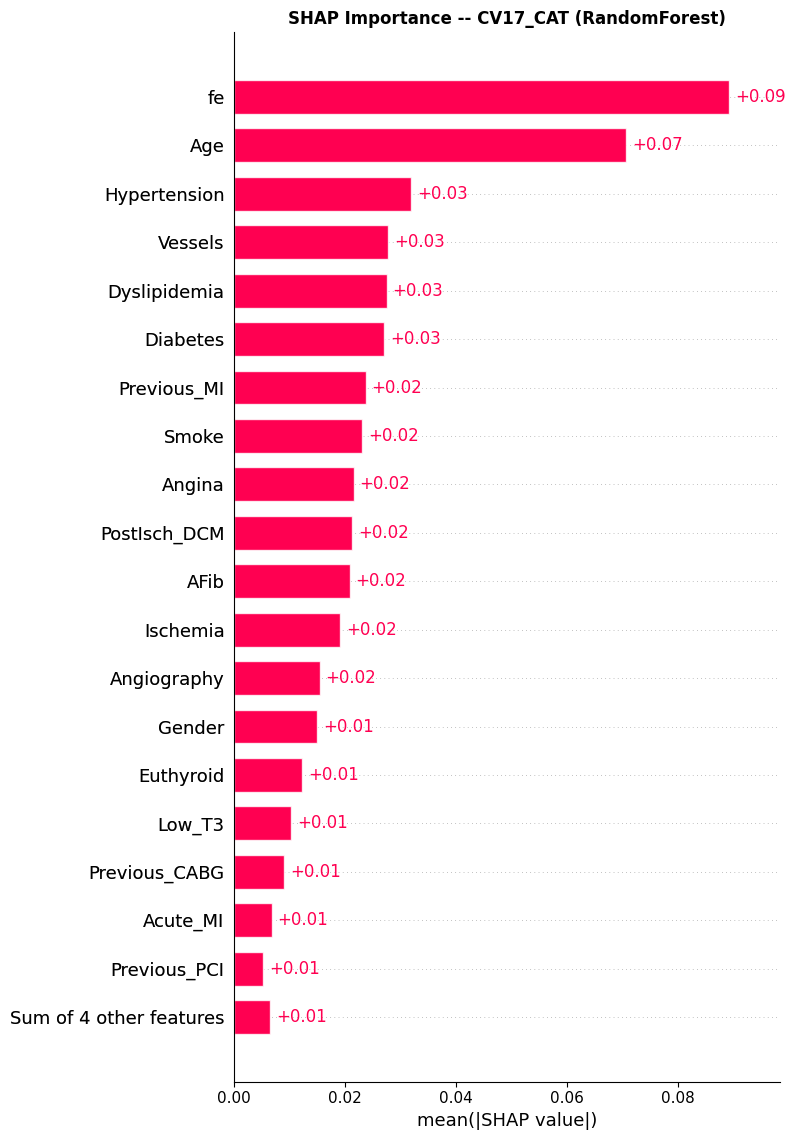

**CV17_RATIO**

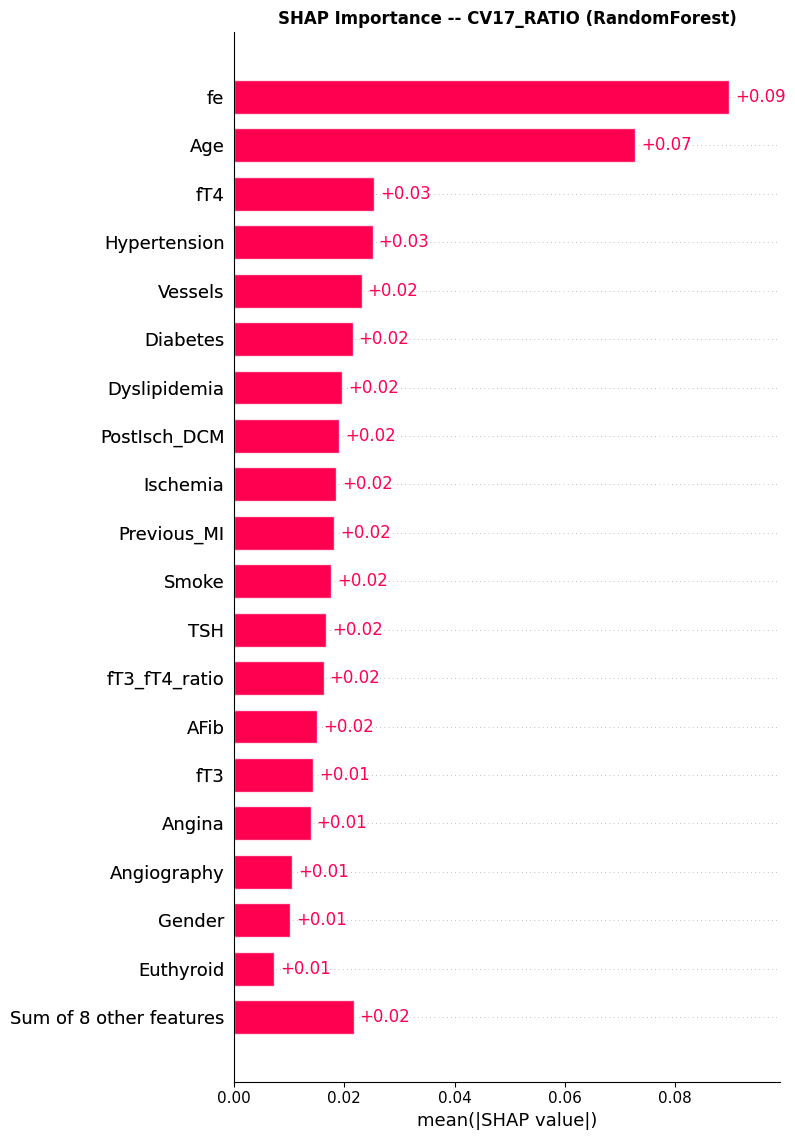

**CV17_RATIO_ONLY**

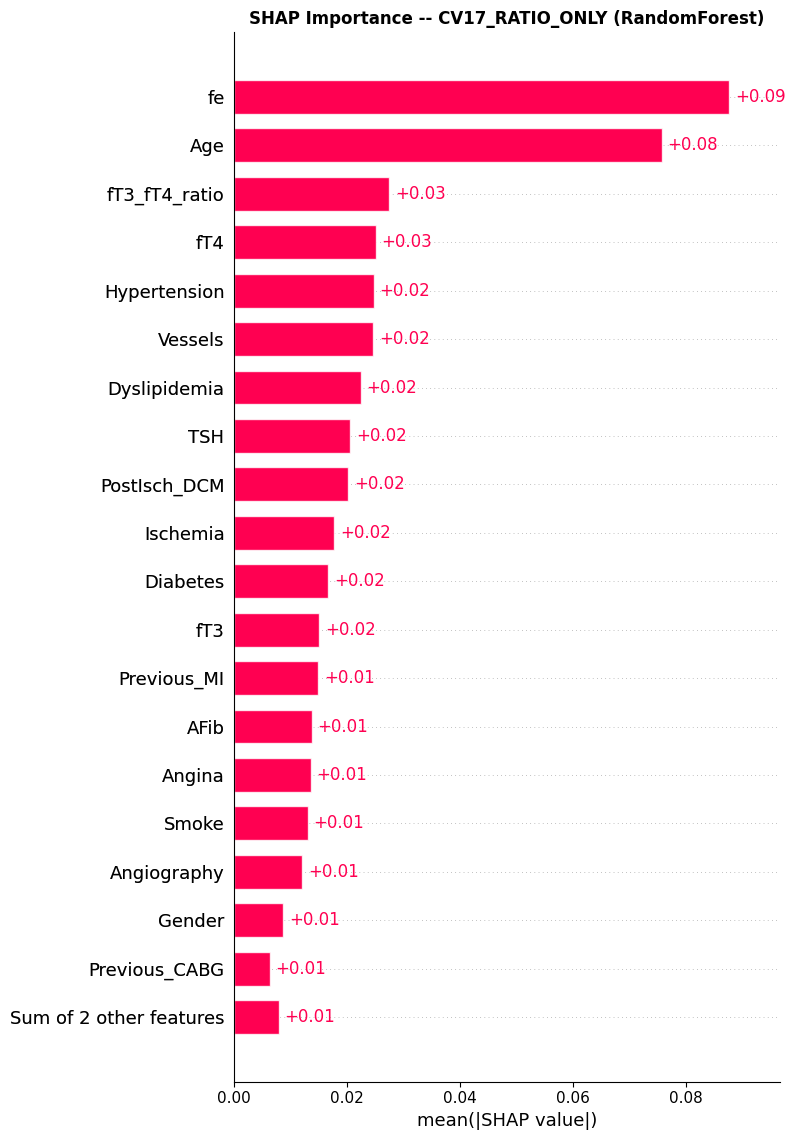

Shown figures for competing: 8


In [5]:
for cohort in ['strict', 'competing']:
    display(Markdown(f'### Cohort: {cohort}'))
    shown = 0
    for fs in FEATURE_SETS:
        path = FIGURES / f'shap_bar_{cohort}_{fs}.png'
        legacy = FIGURES / f'shap_bar_{fs}.png'
        if not path.exists() and cohort == 'strict' and legacy.exists():
            path = legacy
        if path.exists():
            display(Markdown(f'**{fs}**'))
            show_image(path, width=760)
            shown += 1
        else:
            print(f'{fs}: missing')
    print(f'Shown figures for {cohort}: {shown}')

## 5.4 Calibration

Calibration is meant for probability quality, not for maximizing F1 at the default threshold. The updated code calibrates all valid cohort/feature-set pairs after rerun.

,cohort,feature_set,method,brier_score,roc_auc,f1_macro_default,selected_threshold,f1_macro_selected_threshold,model,sampler,best_params,selection_source,selection_score,n_train,n_test
0,strict,CV17,base,0.141831,0.843862,0.731782,0.660,0.744825,LogisticRegression,SVMSMOTE,"{'clf__penalty': 'l2', 'clf__C': 0.1}",tuning,0.734675,3073,1317
1,strict,CV17,isotonic,0.108501,0.844563,0.692555,0.660,0.617137,LogisticRegression,SVMSMOTE,"{'clf__penalty': 'l2', 'clf__C': 0.1}",tuning,0.734675,3073,1317
2,strict,CV17,sigmoid,0.108813,0.844620,0.697317,0.660,0.606592,LogisticRegression,SVMSMOTE,"{'clf__penalty': 'l2', 'clf__C': 0.1}",tuning,0.734675,3073,1317
3,strict,CV17_THY26,base,0.114778,0.837306,0.748970,0.485,0.747865,HistGradientBoosting,SVMSMOTE,"{'clf__min_samples_leaf': 40, 'clf__max_iter':...",tuning,0.735016,3073,1317
4,strict,CV17_THY26,isotonic,0.104353,0.845224,0.709124,0.485,0.716787,HistGradientBoosting,SVMSMOTE,"{'clf__min_samples_leaf': 40, 'clf__max_iter':...",tuning,0.735016,3073,1317
5,strict,CV17_THY26,sigmoid,0.104805,0.845883,0.715880,0.485,0.718820,HistGradientBoosting,SVMSMOTE,"{'clf__min_samples_leaf': 40, 'clf__max_iter':...",tuning,0.735016,3073,1317
6,strict,CV17_BIN,base,0.119211,0.846340,0.753450,0.535,0.757146,XGBoost,SVMSMOTE,"{'clf__subsample': 1.0, 'clf__n_estimators': 2...",tuning,0.730162,3073,1317
7,strict,CV17_BIN,isotonic,0.105526,0.847819,0.715280,0.535,0.690448,XGBoost,SVMSMOTE,"{'clf__subsample': 1.0, 'clf__n_estimators': 2...",tuning,0.730162,3073,1317
8,strict,CV17_BIN,sigmoid,0.105390,0.848068,0.726663,0.535,0.716755,XGBoost,SVMSMOTE,"{'clf__subsample': 1.0, 'clf__n_estimators': 2...",tuning,0.730162,3073,1317
9,strict,CV17_ORD,base,0.139316,0.845371,0.729675,0.640,0.753200,LogisticRegression,SVMSMOTE,"{'clf__penalty': 'l2', 'clf__C': 1}",tuning,0.733697,3073,1317


,cohort,feature_set,n_methods
0,competing,CV17,3
1,competing,CV17_BIN,3
2,competing,CV17_CAT,3
3,competing,CV17_CONT,3
4,competing,CV17_ORD,3
5,competing,CV17_RATIO,3
6,competing,CV17_RATIO_ONLY,3
7,competing,CV17_THY26,3
8,strict,CV17,3
9,strict,CV17_BIN,3


### Cohort: strict

**CV17**

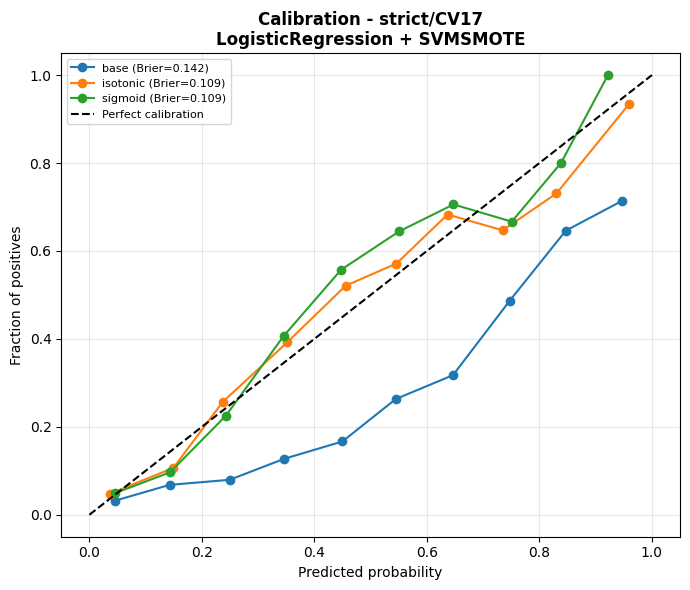

**CV17_THY26**

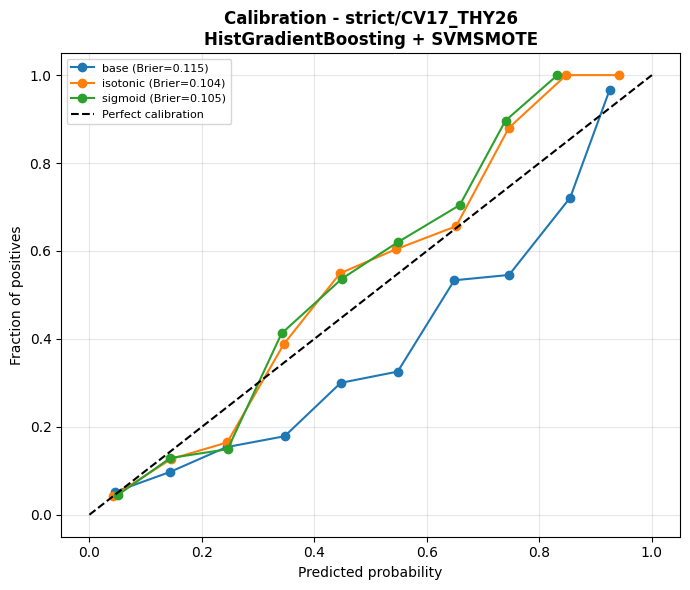

**CV17_BIN**

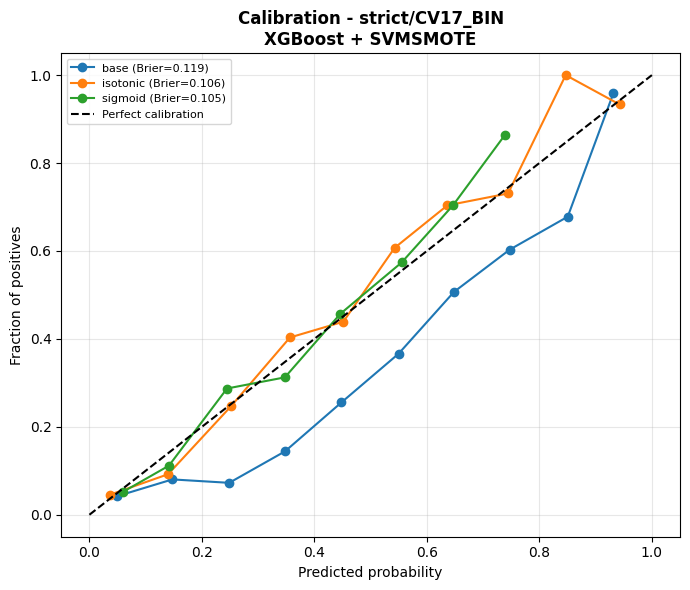

**CV17_ORD**

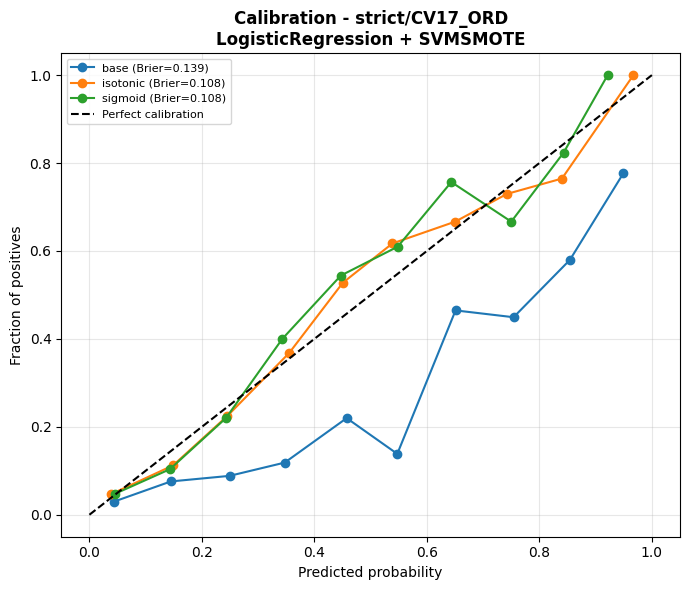

**CV17_CONT**

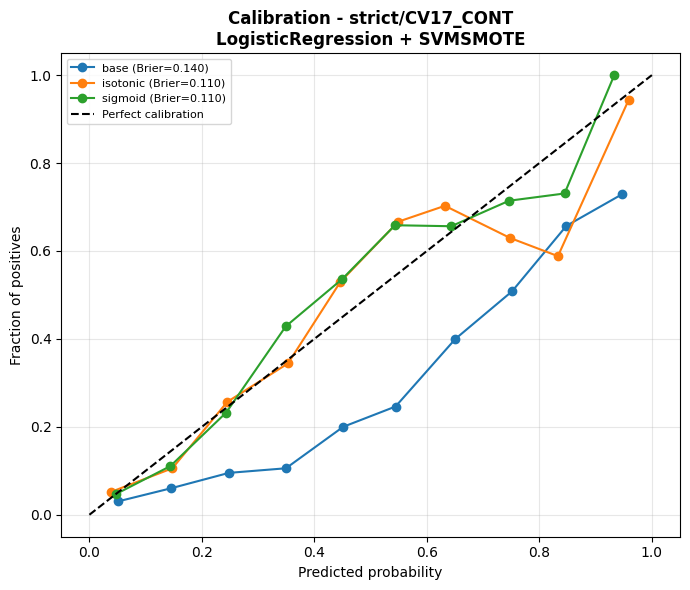

**CV17_CAT**

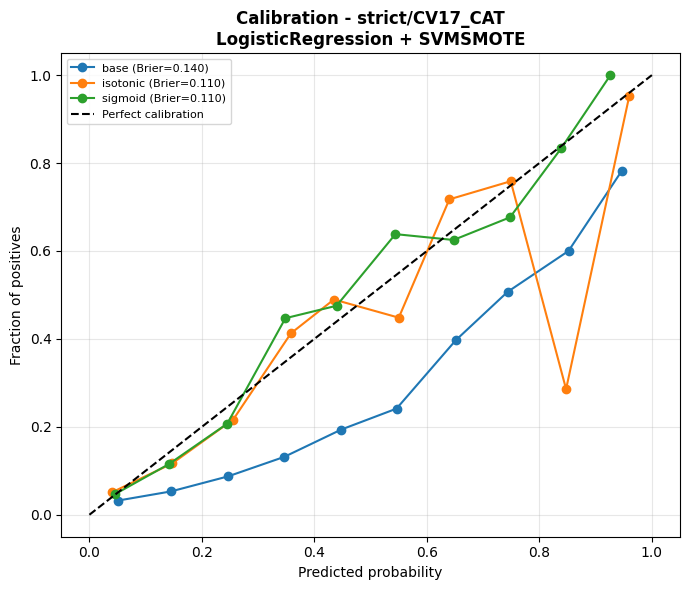

**CV17_RATIO**

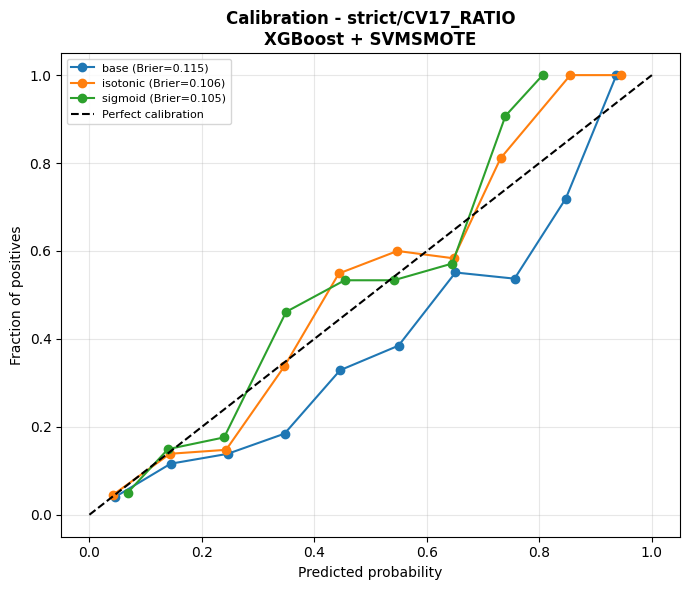

**CV17_RATIO_ONLY**

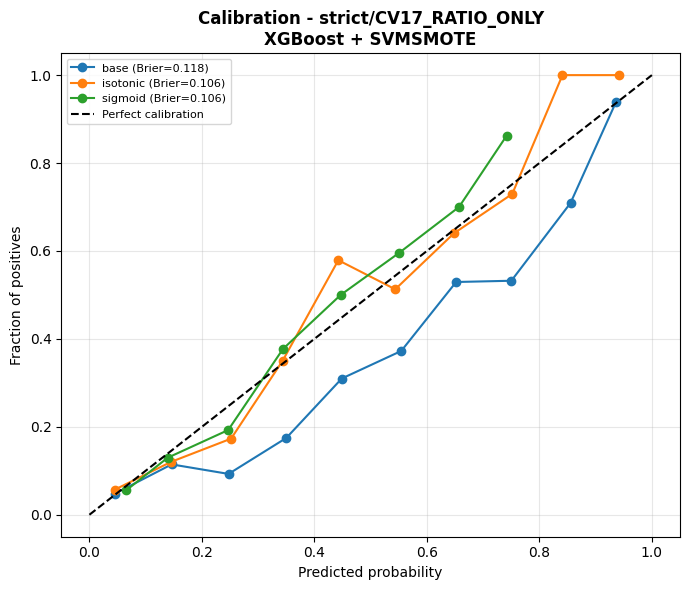

Shown calibration figures for strict: 8


### Cohort: competing

**CV17**

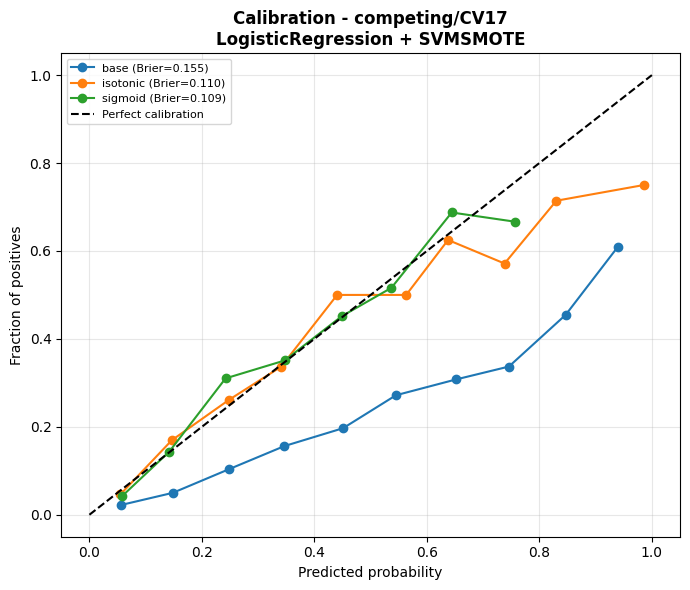

**CV17_THY26**

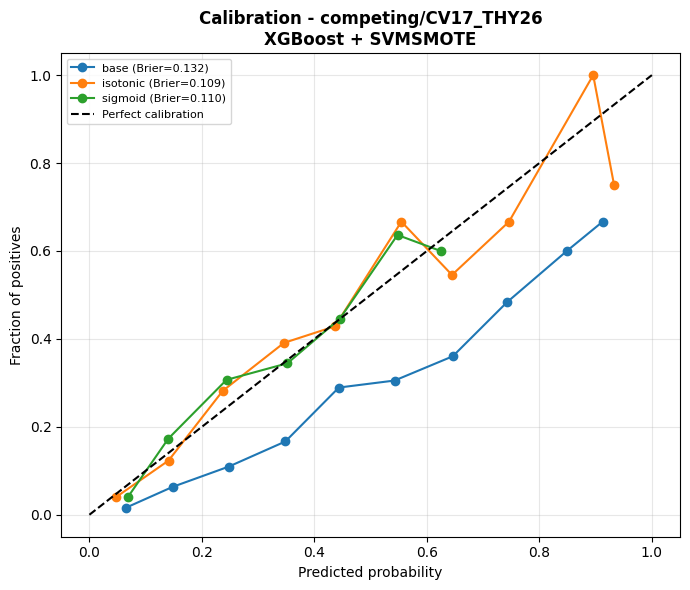

**CV17_BIN**

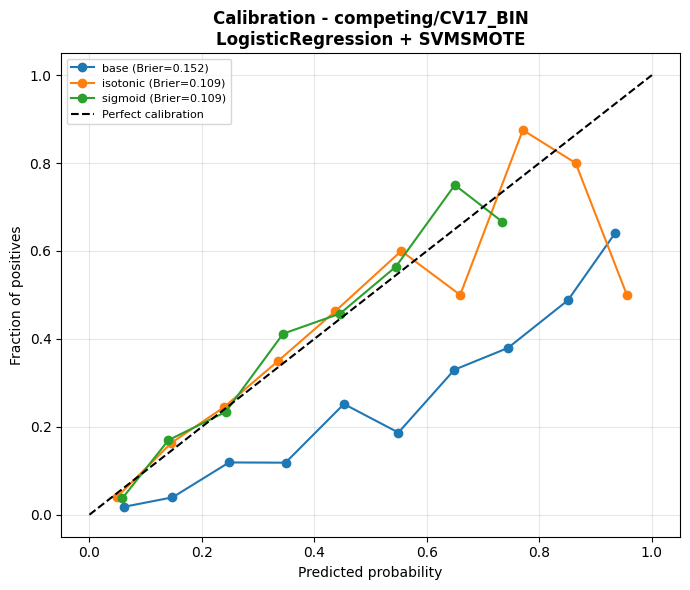

**CV17_ORD**

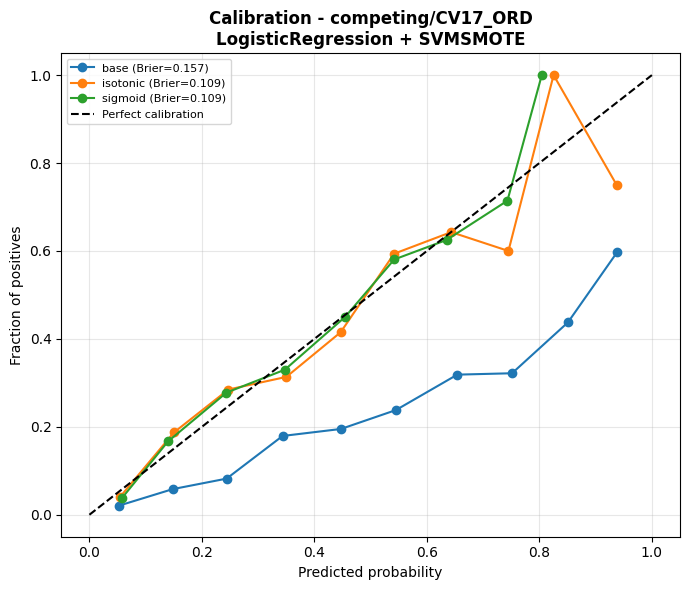

**CV17_CONT**

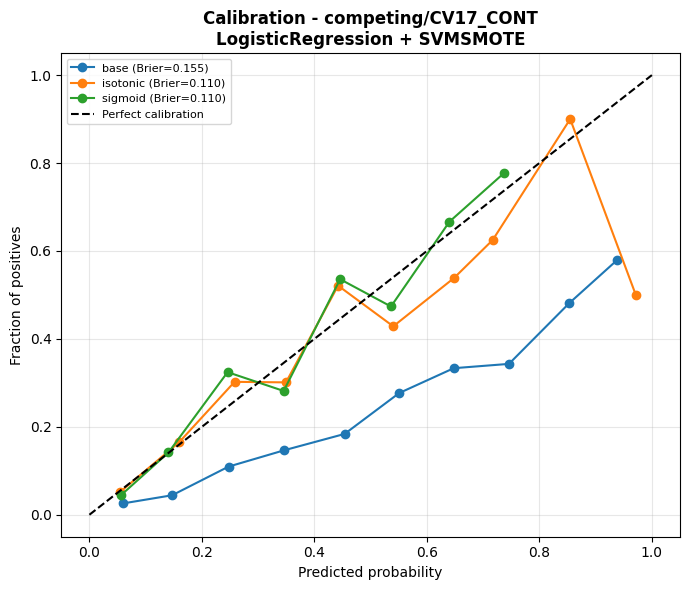

**CV17_CAT**

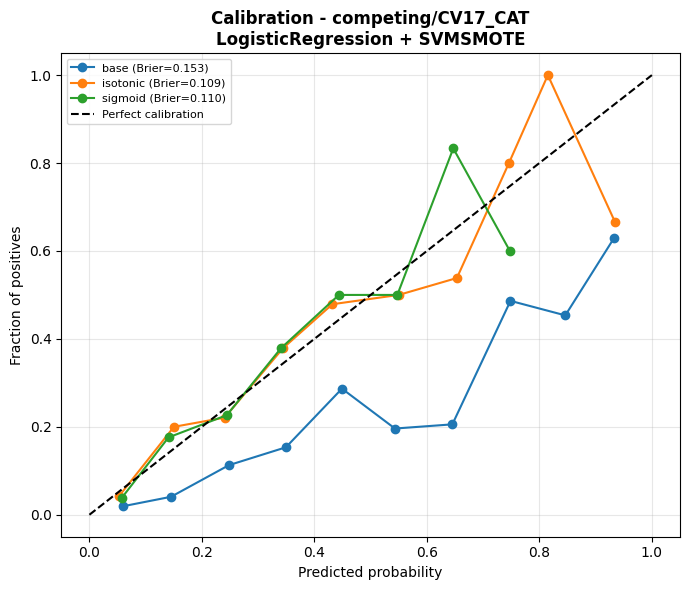

**CV17_RATIO**

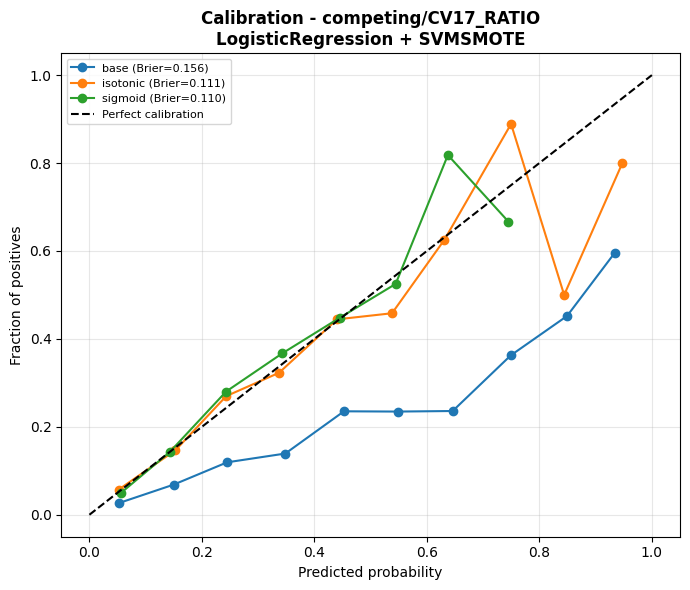

**CV17_RATIO_ONLY**

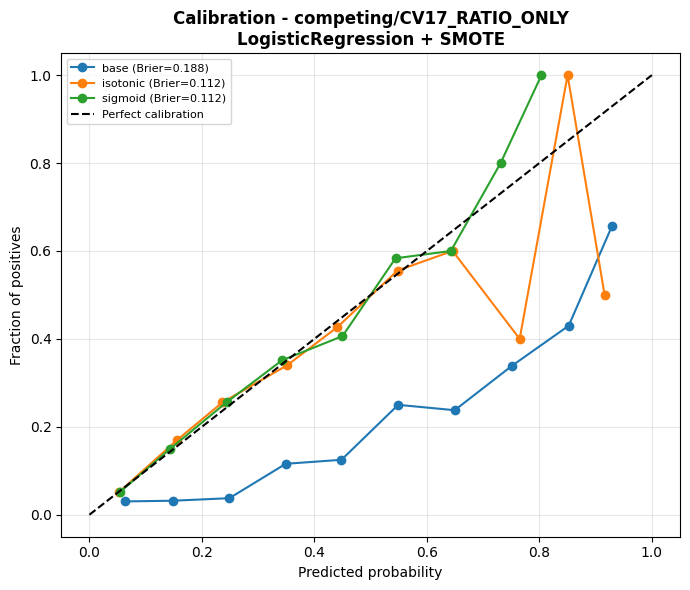

Shown calibration figures for competing: 8


In [6]:
cal_path = REPORTS / 'calibration_results.csv'
if cal_path.exists():
    cal = pd.read_csv(cal_path)
    display(cal)
    if {'cohort','feature_set','method'}.issubset(cal.columns):
        completeness = cal.groupby(['cohort','feature_set'])['method'].nunique().reset_index(name='n_methods')
        display(completeness)
else:
    print('No calibration results.')

for cohort in ['strict', 'competing']:
    display(Markdown(f'### Cohort: {cohort}'))
    shown = 0
    for fs in FEATURE_SETS:
        path = FIGURES / f'calibration_curve_{cohort}_{fs}.png'
        legacy = FIGURES / 'calibration_curve.png'
        if not path.exists() and cohort == 'strict' and fs == 'CV17_THY26' and legacy.exists():
            path = legacy
        if path.exists():
            display(Markdown(f'**{fs}**'))
            show_image(path, width=760)
            shown += 1
    print(f'Shown calibration figures for {cohort}: {shown}')

## Take-home message

- SHAP/permutation are interpretability checks, not proof of incremental predictive performance.
- Calibration should be discussed separately from classification threshold performance.
- If artefacts are legacy, rerun `python run_pipeline.py --step shap --force` and `python run_pipeline.py --step calibration`.